#Loading Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from wordcloud import WordCloud

In [2]:
df = pd.read_csv("/content/drive/MyDrive/ML Projects/archive (1).zip")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.shape

(8807, 12)

#Data cleaning and preprocessing

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [6]:
df['director'] = df['director'].fillna('unknown')
df['cast'] = df['cast'].fillna('unknown')

In [7]:
mode_country = df['country'].mode()[0]
df['country'] = df['country'].fillna(mode_country)

In [8]:
df.dropna(subset = ['date_added', 'rating', 'duration'], inplace = True)
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


#Data-Type inconsistency Handling

In [9]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', dayfirst=False)

#Feature Engineering

In [10]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   object        
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   cast          8790 non-null   object        
 5   country       8790 non-null   object        
 6   date_added    8790 non-null   datetime64[ns]
 7   release_year  8790 non-null   int64         
 8   rating        8790 non-null   object        
 9   duration      8790 non-null   object        
 10  listed_in     8790 non-null   object        
 11  description   8790 non-null   object        
 12  year_added    8790 non-null   int32         
 13  month_added   8790 non-null   int32         
dtypes: datetime64[ns](1), int32(2), int64(1), object(10)
memory usage: 961.4+ KB


#EDA : Exploratary Data Analysis

#Univariate - Analysis

In [11]:
type_counts = df['type'].value_counts()
type_counts

,count
type,
Movie,6126
TV Show,2664


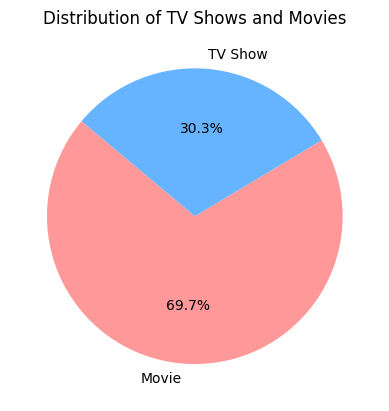

In [12]:
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('Distribution of TV Shows and Movies')
plt.show()

In [13]:
content_added_over_time = df.groupby(['year_added', 'type']).size().unstack().fillna(0)
content_added_over_time

type,Movie,TV Show
year_added,,
2008,1.0,1.0
2009,2.0,0.0
2010,1.0,0.0
2011,13.0,0.0
2012,3.0,0.0
2013,6.0,5.0
2014,19.0,5.0
2015,56.0,26.0
2016,251.0,175.0


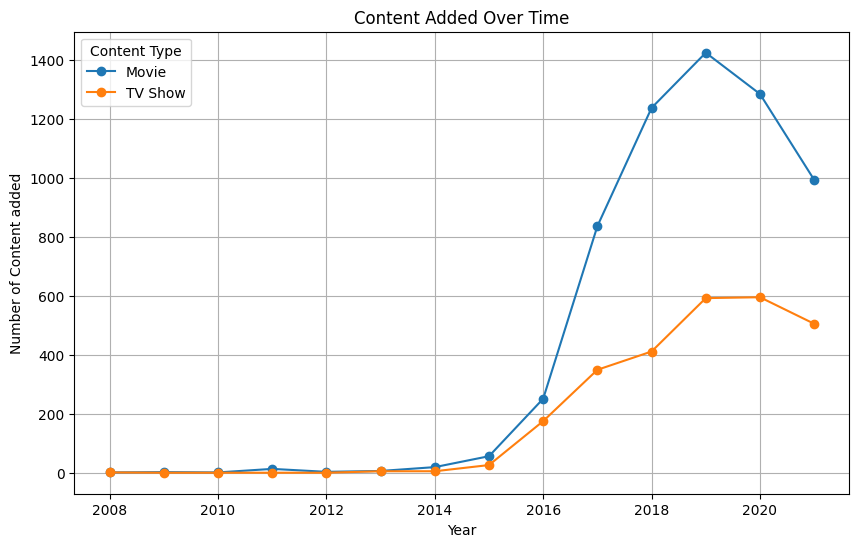

In [14]:
content_added_over_time.plot(kind='line', marker='o', figsize=(10, 6))
plt.title('Content Added Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Content added')
plt.legend(title='Content Type')
plt.grid(True)
plt.show()

In [15]:
genres = df.assign(genres=df['listed_in'].str.split(',')).explode('genres')
genres

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,genres
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,Documentaries
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,International TV Shows
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,TV Dramas
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,TV Mysteries
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,Crime TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020,1,Children & Family Movies
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020,1,Comedies
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019,3,Dramas
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019,3,International Movies


#Popular genres

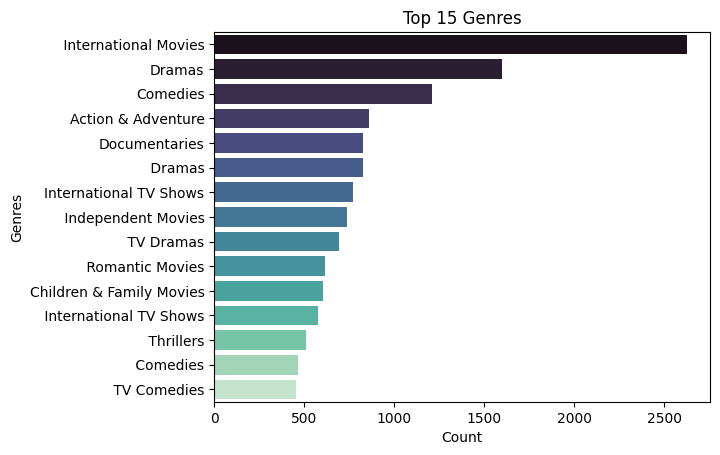

In [16]:
#Top 15 genres and their counts
top_genres = genres['genres'].value_counts().reset_index()

#Rename Column
top_genres.columns = ['genres', 'count']

#Top 15 for plotting
top_genres_for_plot = top_genres.head(15)

sns.barplot(y='genres', x='count', data=top_genres_for_plot, palette='mako', hue='genres', legend=False)
plt.title('Top 15 Genres')
plt.xlabel('Count')
plt.ylabel('Genres')
plt.show()

Insight : International movies are the most common genre highlighting the netflix global content strategy

#Distribution of content duration

In [17]:
movies = df[df['type'] == 'Movie'].copy()
tv_shows = df[df['type'] == 'TV Show'].copy()

In [18]:
movies['duration_mins'] = movies['duration'].str.replace(' min', '').astype(int)
tv_shows['seasons'] = tv_shows['duration'].str.replace(' Seasons', '').str.replace(' Season', '').astype(int)

In [19]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019,11
8803,s8804,TV Show,Zombie Dumb,unknown,unknown,United States,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2019,7
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019,11
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020,1


/tmp/ipykernel_6387/3344309663.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1], data=tv_shows, x='seasons', palette='rocket', order=tv_shows['seasons'].value_counts().index).set_title('TV_show_duration_distribution(seasons)')


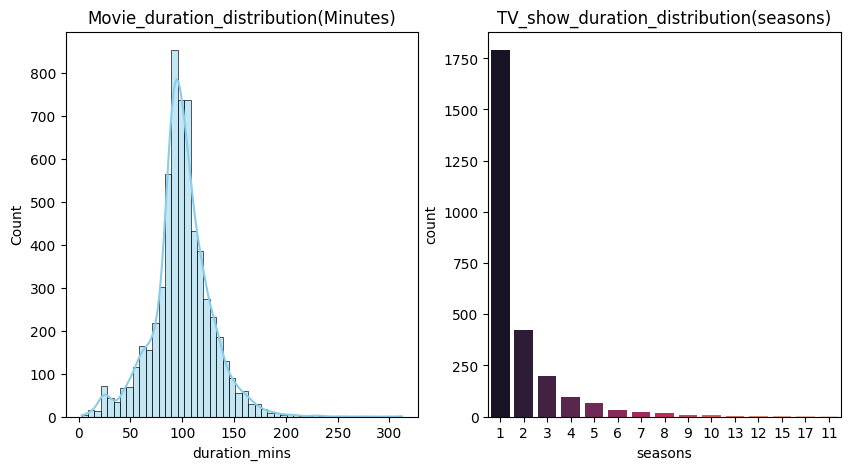

In [20]:
#Plot for distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

#Movie duration distribution
sns.histplot(ax=axes[0], data=movies, x='duration_mins', bins=50, kde=True, color='skyblue').set_title('Movie_duration_distribution(Minutes)')

#Movie duration distribution
sns.countplot(ax=axes[1], data=tv_shows, x='seasons', palette='rocket', order=tv_shows['seasons'].value_counts().index).set_title('TV_show_duration_distribution(seasons)')

plt.show()

Insight :
- The majority of the movies on Netflix are in the range between 80-120 mins duration, which is ideally standard runtime for feature films

- The vast majority of the TV shows on Netflix are short-lived with most having only 1 season. This could also tells strategy of producing many plots and reviewing the most successful one's or focus limited series

In [21]:
#Handle the multi country listing similar the genres
countries = df.assign(country=df['country'].str.split(',')).explode('country')

#Get top 15 countries and their counts
top_countries = countries['country'].value_counts().reset_index()
top_countries.columns = ['country', 'count']

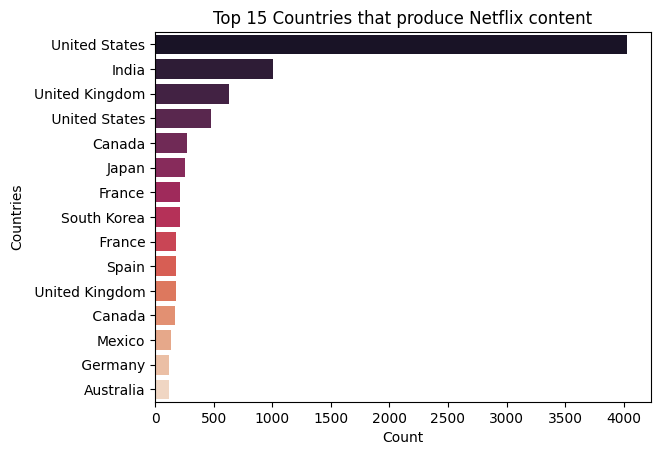

In [22]:
#Top 15 countries for plotting
top_countries_for_plot = top_countries.head(15)

sns.barplot(y='country', x='count', data=top_countries_for_plot, palette='rocket', hue='country', legend=False)
plt.title('Top 15 Countries that produce Netflix content')
plt.xlabel('Count')
plt.ylabel('Countries')
plt.show()

Insights : US is the largest content producing country available on Netflix followed by India

#Maturity ratings

/tmp/ipykernel_6387/1431211764.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='rocket', order=df['rating'].value_counts().index)


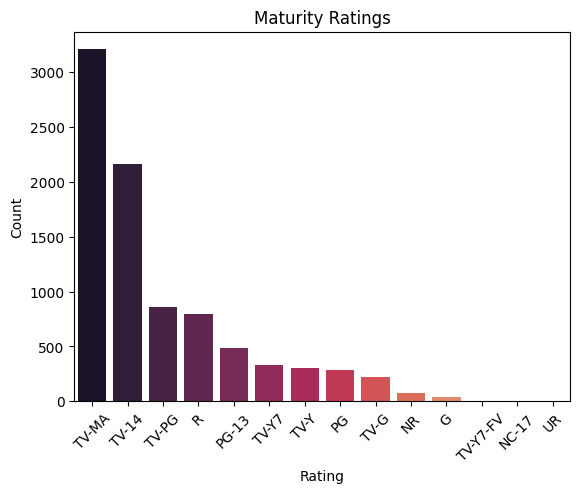

In [23]:
sns.countplot(x='rating', data=df, palette='rocket', order=df['rating'].value_counts().index)
plt.title('Maturity Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

Insight : Large portion of Netflix content is targeting mature audience with TV-MA(Mature Audience) and TV-14(under guidence of parents)

#Feature Engineering 2

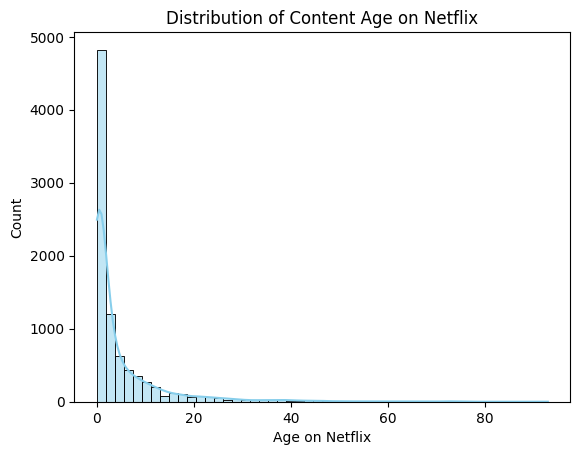

In [24]:
#Creating an new feature
df['age_on_netflix'] = df['year_added'] - df['release_year']

#Filter out any potential errors where added year is before release year
content_age = df[df['age_on_netflix'] >= 0]

sns.histplot(data = content_age, x='age_on_netflix', bins=50, kde=True, color='skyblue')
plt.title('Distribution of Content Age on Netflix')
plt.xlabel('Age on Netflix')
plt.ylabel('Count')
plt.show()

Insight : The large spike at zero indicates that significant amount of content added in same year

#Multivariate - Analysis

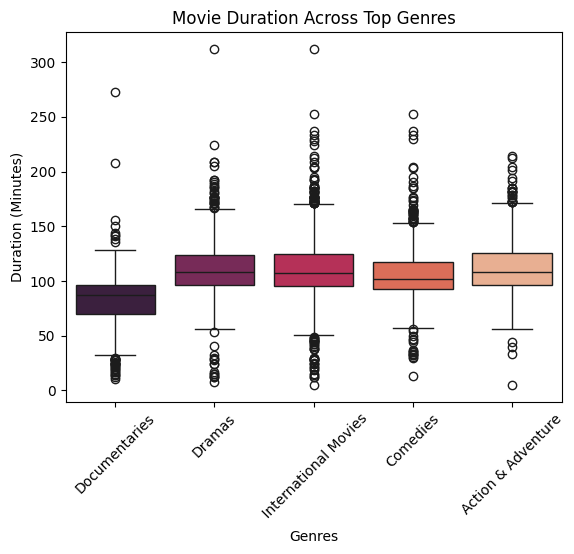

In [25]:
top_genres = genres['genres'].value_counts().index[:5]
genres_movies = genres[(genres['type'] == 'Movie') & (genres['genres'].isin(top_genres))].copy()
genres_movies['duration_mins'] = genres_movies['duration'].str.replace(' min', '').astype(int)

sns.boxplot(x='genres', y='duration_mins', data=genres_movies, palette='rocket', hue='genres', legend=False)
plt.title('Movie Duration Across Top Genres')
plt.xlabel('Genres')
plt.ylabel('Duration (Minutes)')
plt.xticks(rotation=45)
plt.show()

Insight : International Movies & Dramas contains more outliers and shows various film making styles around world

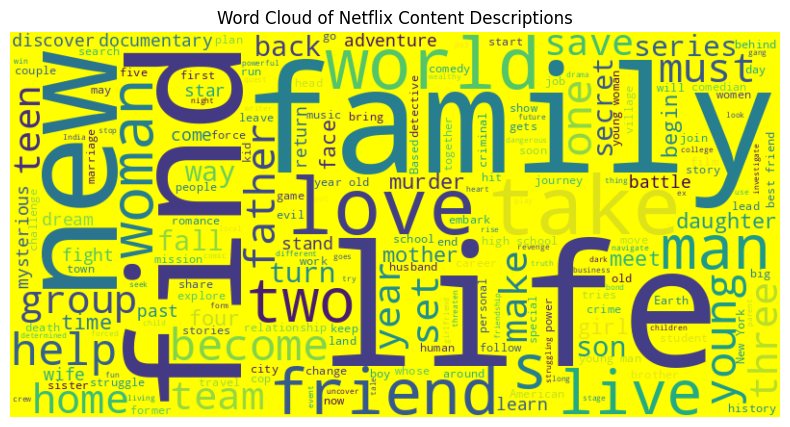

In [26]:
#Adding all descriptions into single string
text = ' '.join(df['description'])

#Generate word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='yellow').generate(text)

#Display generated image
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Netflix Content Descriptions')
plt.show()

The world cloud highlights common themes and subjects. words like 'family', 'life', 'love', 'father', 'live' etc are common. Suggesting that more of netflix content revolves around human relationships and personal journeys